# Lane C eval analysis

Summary statistics and graphs for the blind human ratings collected by `eval/app.py`, plus the automatic metrics written alongside them by `eval/generate_samples.py`.

Re-run this notebook any time after a scoring session in the Streamlit app (`streamlit run eval/app.py`) to refresh the numbers. It reads whatever is currently on disk in `eval/scores.csv` (primary `card` condition) and `eval/scores_nocard_ablation.csv` (ablation), so partial scoring runs are fine — the coverage counts below say how much of the 100-prompt set is in each table.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EVAL_DIR = Path(".") if Path("scores.csv").exists() else Path("eval")
SCORES = EVAL_DIR / "scores.csv"
SCORES_NOCARD = EVAL_DIR / "scores_nocard.csv"

AXES = ["grammar", "factual_correctness", "storytelling_creativity", "coherence"]
ERROR_TAGS = [
    "Omission",
    "Contradiction",
    "Unconstrained invention",
    "Encyclopedia dump",
    "Story domination",
]
SYSTEM_ORDER = ["B0", "B1", "M2"]

plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv(SCORES)
systems = [s for s in SYSTEM_ORDER if s in df["system_id"].unique()] or sorted(df["system_id"].unique())

print(f"Loaded          : {SCORES}")
print(f"Rows scored     : {len(df)}")
print(f"Systems         : {', '.join(systems)}")
print(f"Prompts covered : {df.groupby('system_id')['prompt_id'].nunique().to_dict()}")
if "condition" in df.columns and df["condition"].nunique() > 1:
    print("WARNING: multiple conditions in this file -- split before reporting.")

df.head()

Loaded          : scores.csv
Rows scored     : 180
Systems         : B0, B1, M2
Prompts covered : {'B0': 60, 'B1': 60, 'M2': 60}


,timestamp,prompt_id,card_id,condition,prompt_text,shown_label,system_id,story_text,grammar,factual_correctness,storytelling_creativity,coherence,error_tags,perplexity,num_tokens
0,2026-07-26T20:50:13.860233+00:00,p001,fc_healing_21,card,Topic: Healing\r\n\r\nFacts:\r\n1. Healing is ...,Model A,M2,"In screen lab, Tom watched a film about a proc...",3,3,4,3,NaN,6.010656,170
1,2026-07-26T20:50:13.860233+00:00,p001,fc_healing_21,card,Topic: Healing\r\n\r\nFacts:\r\n1. Healing is ...,Model B,B0,The moral of this story is to always try to be...,4,1,3,4,NaN,7.796106,32
2,2026-07-26T20:50:13.860233+00:00,p001,fc_healing_21,card,Topic: Healing\r\n\r\nFacts:\r\n1. Healing is ...,Model C,B1,Fources\r\n19.w.et civilage of the Secutions o...,1,1,1,1,NaN,4.767048,300
3,2026-07-26T20:53:27.251501+00:00,p002,fc_ink_23,card,Topic: Ink\r\n\r\nFacts:\r\n1. Ink is a liquid...,Model A,B0,No matter how hard the language began. But no ...,4,1,3,4,NaN,5.453204,69
4,2026-07-26T20:53:27.251501+00:00,p002,fc_ink_23,card,Topic: Ink\r\n\r\nFacts:\r\n1. Ink is a liquid...,Model B,B1,References \r\n\r\nOther websites \r\n Officia...,1,1,1,1,NaN,3.376223,51


## Human ratings (1–5, higher is better)

Mean Likert score per system on each rubric axis. See `eval/rubric.md` for what each score means.

In [3]:
ratings = df.groupby("system_id")[AXES].mean().reindex(systems)
counts = df.groupby("system_id").size().reindex(systems)
ratings.insert(0, "n", counts)
ratings.round(2)

,n,grammar,factual_correctness,storytelling_creativity,coherence
system_id,,,,,
B0,60,3.50,1.00,3.38,3.38
B1,60,2.12,1.00,1.02,1.22
M2,60,3.43,3.72,3.85,3.52


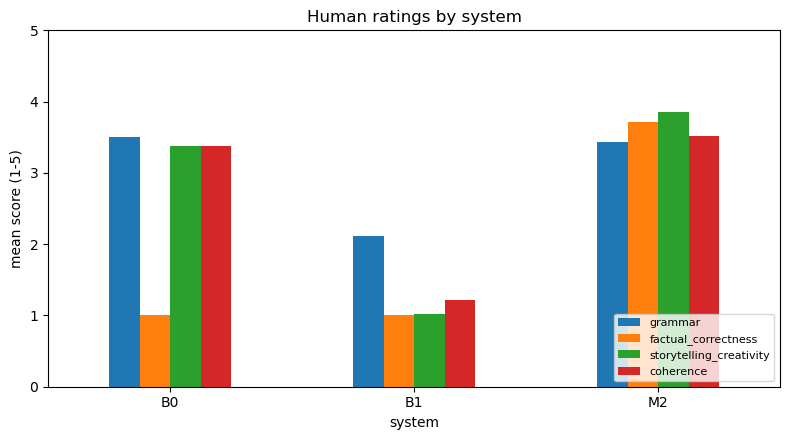

In [4]:
ax = ratings[AXES].plot(kind="bar", figsize=(8, 4.5), ylim=(0, 5))
ax.set_ylabel("mean score (1-5)")
ax.set_xlabel("system")
ax.set_title("Human ratings by system")
ax.legend(loc="lower right", fontsize=8)
ax.set_xticklabels(ratings.index, rotation=0)
plt.tight_layout()
plt.show()

## Supporting automatic metrics

Perplexity is each story's score under its **own** generating model — a fluency/confidence proxy, not a quality measure (it rewards repetitive degeneration). Treat it as supporting evidence next to the human ratings above, never on its own — see `eval/rubric.md`.

In [5]:
auto = df.groupby("system_id").agg(
    mean_ppl=("perplexity", "mean"),
    median_ppl=("perplexity", "median"),
    mean_story_tokens=("num_tokens", "mean"),
).reindex(systems)
auto.round(1)

,mean_ppl,median_ppl,mean_story_tokens
system_id,,,
B0,17.4,14.9,46.7
B1,6.9,6.1,115.6
M2,4.0,4.0,195.5


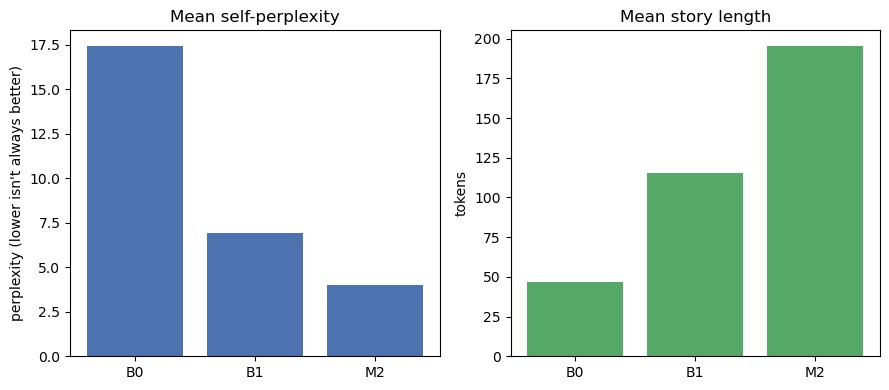

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(auto.index, auto["mean_ppl"], color="#4C72B0")
axes[0].set_title("Mean self-perplexity")
axes[0].set_ylabel("perplexity (lower isn't always better)")

axes[1].bar(auto.index, auto["mean_story_tokens"], color="#55A868")
axes[1].set_title("Mean story length")
axes[1].set_ylabel("tokens")

plt.tight_layout()
plt.show()

## Error tag analysis

Optional multi-select tags applied while scoring. Counts below are how many rated stories per system carry each tag (a story can carry more than one).

In [7]:
tag_rows = []
for system in systems:
    tags_series = df.loc[df["system_id"] == system, "error_tags"].fillna("")
    counts = {tag: 0 for tag in ERROR_TAGS}
    for raw in tags_series:
        for tag in str(raw).split(";"):
            tag = tag.strip()
            if tag in counts:
                counts[tag] += 1
    tag_rows.append({"system_id": system, **counts})

tag_df = pd.DataFrame(tag_rows).set_index("system_id")
n_tagged = (df["error_tags"].fillna("").str.strip() != "").sum()

if n_tagged == 0:
    print(f"No error tags recorded on any of {len(df)} rows yet -- tag while scoring to populate this section.")
else:
    display(tag_df)
    ax = tag_df.plot(kind="bar", stacked=True, figsize=(8, 4.5))
    ax.set_ylabel("tagged stories")
    ax.set_title("Error tags by system")
    ax.set_xticklabels(tag_df.index, rotation=0)
    ax.legend(loc="upper right", fontsize=7)
    plt.tight_layout()
    plt.show()

No error tags recorded on any of 180 rows yet -- tag while scoring to populate this section.


## Prompt ablation: card vs. nocard

Same 100 topics, paired by prompt id: `card` gives the model the fact card in context (the primary result); `nocard` gives only a bare first-fact sentence. This is the ablation, not the headline result — skip this section if `scores_nocard_ablation.csv` hasn't been scored yet.

card                                                        \
          grammar factual_correctness storytelling_creativity coherence   
system_id                                                                 
B0           3.50                1.00                    3.38      3.38   
B1           2.12                1.00                    1.02      1.22   
M2           3.43                3.72                    3.85      3.52   

           nocard                                                        
          grammar factual_correctness storytelling_creativity coherence  
system_id                                                                
B0           3.55                1.10                    3.15      3.45  
B1           1.75                1.05                    1.20      1.40  
M2           1.60                1.00                    1.05      1.05

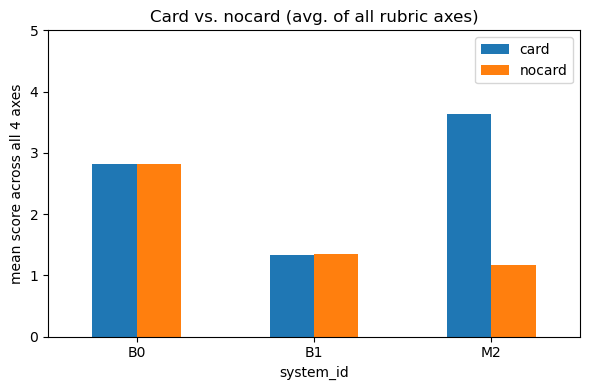

In [8]:
if SCORES_NOCARD.exists():
    df_nc = pd.read_csv(SCORES_NOCARD)
    if len(df_nc):
        ratings_nc = df_nc.groupby("system_id")[AXES].mean().reindex(systems)
        combined = pd.concat({"card": ratings[AXES], "nocard": ratings_nc}, axis=1)
        display(combined.round(2))

        overall = pd.DataFrame({
            "card": ratings[AXES].mean(axis=1),
            "nocard": ratings_nc[AXES].mean(axis=1),
        }).reindex(systems)
        ax = overall.plot(kind="bar", figsize=(6, 4), ylim=(0, 5))
        ax.set_ylabel("mean score across all 4 axes")
        ax.set_title("Card vs. nocard (avg. of all rubric axes)")
        ax.set_xticklabels(overall.index, rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{SCORES_NOCARD} exists but has no scored rows yet.")
else:
    print(f"No ablation scores file at {SCORES_NOCARD}.")